# Denoising VAE

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from src.models import VAE, vae_loss

from src.data_preprocessing import (
    read_oscilloscope_data, 
    segment_signal,
    normalize_segment,
    perform_fft_on_segments
)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


In [3]:
###############################################################################
# Training Loop
###############################################################################

def train_vae(
    model, 
    dataloader, 
    optimizer, 
    device='cpu', 
    num_epochs=20,
    # KL annealing:
    beta_start=0.0, 
    beta_end=1.0,
    # Smoothness & Huber:
    smoothness_weight=0.0, 
    delta=1.0
):
    """
    Train the VAE using Huber-based reconstruction, 
    Adaptive KL annealing (from beta_start -> beta_end), 
    and optional total variation & EMA.

    Args:
      model (nn.Module): the VAE model instance
      dataloader (DataLoader): training data
      optimizer (torch.optim.Optimizer): optimizer
      device (str or torch.device)
      num_epochs (int)
      beta_start (float): initial KL weight
      beta_end (float): final KL weight by the last epoch
      smoothness_weight (float): for total variation
      delta (float): for SmoothL1Loss
      use_ema (bool): if True, maintain an EMA model
      ema_alpha (float): alpha for EMA updates
    """
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        # Linear schedule for beta
        current_beta = beta_start + (beta_end - beta_start) * (epoch / float(num_epochs - 1))

        for batch in dataloader:
            batch_x = batch[0].to(device)
            optimizer.zero_grad()

            x_decoded, mu, logvar = model(batch_x)

            loss = vae_loss(
                x=batch_x,
                x_decoded=x_decoded,
                mu=mu,
                logvar=logvar,
                beta=current_beta,
                smoothness_weight=smoothness_weight,
                delta=delta
            )
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)

        avg_loss = total_loss / len(dataloader.dataset)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Beta={current_beta:.3f}, Loss={avg_loss:.6f}")

    return model

In [22]:
def data_pipeline(file_path):
    signal = read_oscilloscope_data(file_path=file_path)['Data'].to_numpy()

    signal_mean = np.mean(signal)
    signal -= signal_mean


    ################################################################################
    # Segmentation + FFT
    ################################################################################
    segment_length = 20000
    step = 100
    sampling_rate = 10000

    segments = segment_signal(
        signal, 
        segment_length=segment_length, 
        step=step, 
        apply_window=False
    )

    fft_segments, freqs = perform_fft_on_segments(
        segments, 
        f_sampling=sampling_rate, 
        db=True, 
        cutoff_freq=250
    )

    # Normalize FFT segments
    for i in range(fft_segments.shape[0]):
        fft_segments[i, :] = normalize_segment(fft_segments[i, :])[0]

    return fft_segments, freqs

In [23]:
signals_path = [
    '../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    '../data/raw/20_01_1460_об_мин_с_дисбалансом_ротора.txt',
    '../data/raw/0702  перекос фазы A ток фазы А.txt',
    '../data/raw/0702 без перекосов фаза A.txt',
    '../data/raw/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt',
    '../data/raw/нагрузка 100% 11 01.txt',
    '../data/raw/холостой ход 11 01.txt'
]

all_segments_list = [data_pipeline(signal_path)[0] for signal_path in signals_path]
all_segments = np.concatenate(all_segments_list, axis=0)

freqs = data_pipeline(signals_path[0])[1]


In [60]:
for signal_path in signals_path:
    print(f'{signal_path}: {data_pipeline(signal_path)[0].shape}')

../data/raw/0702  межвитковые фазы A ток фазы А.txt: (301, 500)
../data/raw/20_01_1460_об_мин_с_дисбалансом_ротора.txt: (801, 500)
../data/raw/0702  перекос фазы A ток фазы А.txt: (301, 500)
../data/raw/0702 без перекосов фаза A.txt: (801, 500)
../data/raw/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt: (5801, 500)
../data/raw/нагрузка 100% 11 01.txt: (5801, 500)
../data/raw/холостой ход 11 01.txt: (5801, 500)


In [7]:
################################################################################
# Prepare Data for VAE
################################################################################

def prepare_dataloader(segments_t, batch_size):
    segments = segments_t.copy()

    segments_tensor = torch.tensor(segments, dtype=torch.float32)
    # Add channel dimension (expected by Conv1d layers)
    segments_tensor = segments_tensor.unsqueeze(1)  # Shape: [num_segments, 1, segment_length]
    dataset = TensorDataset(segments_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader


################################################################################
# Denoising with VAE
################################################################################

def denoise_signal(model, noisy_segments, device):
    """
    Pass each segment through the trained VAE to obtain reconstructed segments.
    """
    model.eval()
    with torch.no_grad():
        # Convert segments to tensor
        noisy_segments_tensor = torch.tensor(noisy_segments, dtype=torch.float32).unsqueeze(1).to(device)
        reconstructed_segments, _, _ = model(noisy_segments_tensor)
        return reconstructed_segments.squeeze(1).cpu().numpy()

################################################################################
# Instantiate and Train the VAE
################################################################################

num_epochs = 400
lr = 0.0001
weight_decay = 1e-3
latent_dim = 16
input_dim = all_segments.shape[1]
batch_size = 256


model = VAE(input_dim=input_dim, latent_dim=latent_dim, 
            dropout_p=0.6).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

dataloader = prepare_dataloader(all_segments, batch_size=batch_size)

trained_model = train_vae(
    model, 
    dataloader, 
    optimizer,
    device=device,
    num_epochs=num_epochs,
    beta_start=0.0,   
    beta_end=2.0, 
    smoothness_weight=0.5,
    delta=1.0
)

Epoch [5/200], Beta=0.040, Loss=285.064717
Epoch [10/200], Beta=0.090, Loss=239.207587
Epoch [15/200], Beta=0.141, Loss=221.809202
Epoch [20/200], Beta=0.191, Loss=173.985360
Epoch [25/200], Beta=0.241, Loss=166.856034
Epoch [30/200], Beta=0.291, Loss=142.688432
Epoch [35/200], Beta=0.342, Loss=135.299196
Epoch [40/200], Beta=0.392, Loss=127.504478
Epoch [45/200], Beta=0.442, Loss=124.881449
Epoch [50/200], Beta=0.492, Loss=123.014758
Epoch [55/200], Beta=0.543, Loss=122.948561
Epoch [60/200], Beta=0.593, Loss=126.137617
Epoch [65/200], Beta=0.643, Loss=121.963754
Epoch [70/200], Beta=0.693, Loss=120.555475
Epoch [75/200], Beta=0.744, Loss=118.592724
Epoch [80/200], Beta=0.794, Loss=118.764951
Epoch [85/200], Beta=0.844, Loss=120.454428
Epoch [90/200], Beta=0.894, Loss=118.041501
Epoch [95/200], Beta=0.945, Loss=118.384007
Epoch [100/200], Beta=0.995, Loss=118.127038
Epoch [105/200], Beta=1.045, Loss=118.124713
Epoch [110/200], Beta=1.095, Loss=116.600862
Epoch [115/200], Beta=1.146, L

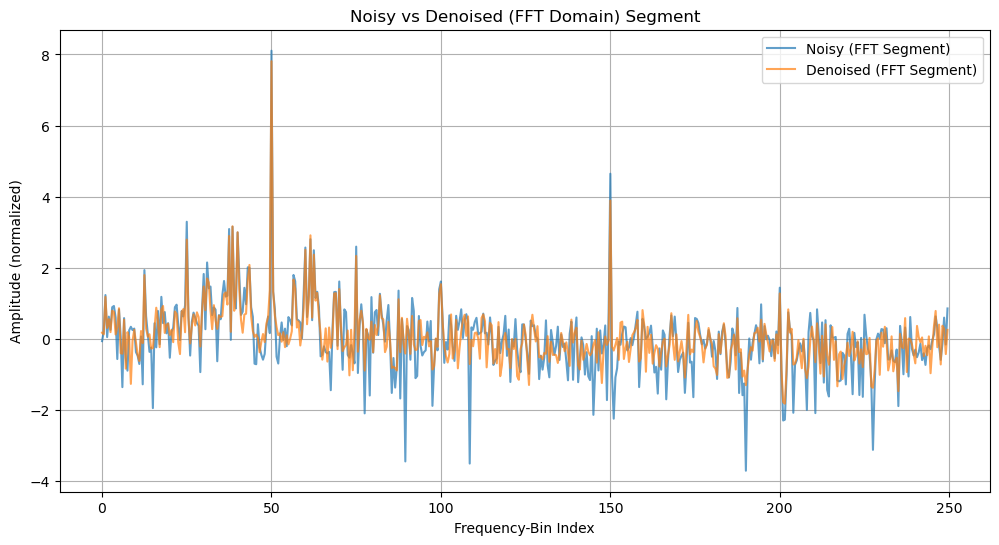

In [48]:
################################################################################
# Apply Denoising
################################################################################
denoised_fft_segments = denoise_signal(trained_model, all_segments, device)

################################################################################
# Plot a Comparison of One FFT Segment
################################################################################
idx_to_plot = 5
plt.figure(figsize=(12, 6))
plt.plot(freqs, all_segments[idx_to_plot], label="Noisy (FFT Segment)", alpha=0.7)
plt.plot(freqs, denoised_fft_segments[idx_to_plot], label="Denoised (FFT Segment)", alpha=0.7)
plt.title("Noisy vs Denoised (FFT Domain) Segment")
plt.xlabel("Frequency-Bin Index")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid()
plt.show()

## VAE sampling smoothing

### Base Model

In [49]:
def denoise_via_sampling(model, x_noisy, n_samples=5):
    """
    x_noisy: shape [1, 1, length] (or [B, 1, length])
    n_samples: how many random draws from latent distribution to decode
    
    Returns:
      recon_avg: averaged reconstructed spectrum [B, 1, length]
      recon_std: standard deviation of reconstructed spectrum [B, 1, length]
    """
    model.eval()
    with torch.no_grad():
        x_dec, mu, logvar = model(x_noisy)

        recons = []
        for _ in range(n_samples):
            z = model.reparameterize(mu, logvar)  # random sample from posterior
            x_decoded_input = model.decoder_input(z)
            x_decoded = model.decoder(x_decoded_input)
            recons.append(x_decoded)

        recons_stacked = torch.stack(recons, dim=0) 
        recon_avg = torch.mean(recons_stacked, dim=0)
        recon_std = torch.std(recons_stacked, dim=0)

    return recon_avg, recon_std


In [71]:
idx_to_test = 0
x_tensor = torch.tensor(all_segments[idx_to_test], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

recon_avg, recon_std = denoise_via_sampling(trained_model, x_tensor, n_samples=1000)
avr_ar = recon_avg.squeeze(0, 1).cpu().numpy()
std_ar = recon_std.squeeze(0, 1).cpu().numpy()

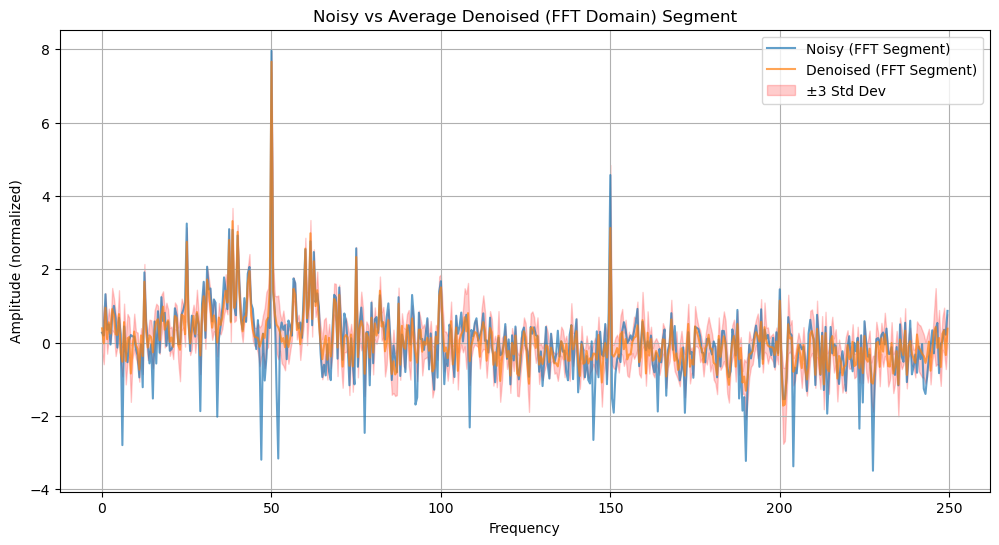

In [72]:
################################################################################
# Plot a Comparison of One FFT Segment
################################################################################
plt.figure(figsize=(12, 6))
plt.plot(freqs, all_segments[idx_to_test], label="Noisy (FFT Segment)", alpha=0.7)
plt.plot(freqs, avr_ar, label="Denoised (FFT Segment)", alpha=0.7)

# Fill between (avg - std) and (avg + std) to visualize uncertainty
std_lower = avr_ar - 3*std_ar
std_upper = avr_ar + 3*std_ar

plt.fill_between(
    freqs,
    std_lower,
    std_upper,
    alpha=0.2,
    color='red',
    label="±3 Std Dev"
)

plt.title("Noisy vs Average Denoised (FFT Domain) Segment")
plt.xlabel("Frequency")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ../data/raw/0702  межвитковые фазы A ток фазы А.txt: (301, 500)
# ../data/raw/20_01_1460_об_мин_с_дисбалансом_ротора.txt: (801, 500)
# ../data/raw/0702  перекос фазы A ток фазы А.txt: (301, 500)
# ../data/raw/0702 без перекосов фаза A.txt: (801, 500)
# ../data/raw/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt: (5801, 500)
# ../data/raw/нагрузка 100% 11 01.txt: (5801, 500)
# ../data/raw/холостой ход 11 01.txt: (5801, 500)